#  Proteomics-Based Comparative Mapping of the Secretomes of Human Brown and White Adipocytes Reveals EPDR1 as a Novel Batokine

Adipokines secreted from white adipose tissue play a role in metabolic crosstalk and homeostasis, whereas the brown adipose secretome is less explored. We performed high-sensitivity mass-spec- trometry-based proteomics on the cell media of human adipocytes derived from the supraclavicular brown ad- ipose and from the subcutaneous white adipose de- pots of adult humans. We identified 471 potentially secreted proteins covering interesting categories such as hormones, growth factors, extracellular matrix
proteins, and proteins of the complement system, which were differentially regulated between brown and white adipocytes. A total of 101 proteins were exclusively quantified in brown adipocytes, and among these was ependymin-related protein 1 (EPDR1). EPDR1 was detected in human plasma, and functional studies suggested a role for EPDR1 in thermogenic determination during adipogenesis. In conclusion, we report substantial differences between the secretomes of brown and white human adipocytes and identify novel candidate batokines that can be important regu- lators of human metabolism. REF: https://www.cell.com/cell-metabolism/fulltext/S1550-4131(19)30556-X

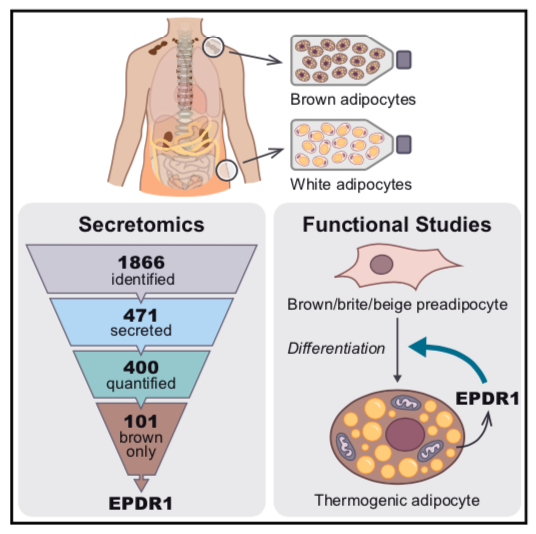




In [ ]:
import os
import re
import pandas as pd
import numpy as np

import ckg_utils
from graphdb_builder import builder_utils, mapping
from graphdb_builder.experiments.parsers import proteomicsParser
from graphdb_connector import connector

from analytics_core.analytics import analytics
from analytics_core.viz import viz

from report_manager import knowledge

from plotly.offline import download_plotlyjs, init_notebook_mode, iplot
%matplotlib inline
init_notebook_mode(connected=True)

In [ ]:
analysis_dir = './local-data)/code/data/tmp/Deshmukh2019'
ckg_utils.checkDirectory(analysis_dir)

pxd_id = 'PXD008541'
file_name='SearchEngineResults_secretome.zip.rar'

## Download Data from PRIDE

We can use functionality in graphdb_builder to directly download data files from EBI's PRIDE database (https://www.ebi.ac.uk/pride/). For that you you just need to specify the PRIDE identifier for the project (PXD...) and the name of the file to download. In this case, the project identifier is PXD008541 and the file we will use is SearchEngineResults_secretome.zip.rar, a RAR compressed file.

In [ ]:
builder_utils.download_PRIDE_data(pxd_id=pxd_id, 
                                  file_name=file_name, 
                                  to=analysis_dir)

## Read Data In

### Decompress File

In [ ]:
builder_utils.unrar(filepath=os.path.join(analysis_dir, file_name), to=analysis_dir)

The list of files within the compressed folder can be listed using the listDirectoryFiles functionality in gaphdb_builder.

In [ ]:
builder_utils.listDirectoryFiles(analysis_dir)

We use the proteinGroups file that contains the proteomics data processed using MaxQuant software.

In [ ]:
proteinGroups_file = os.path.join(analysis_dir, 'proteinGroups.txt')

### Parse Contents

CKG has parsers for MaxQuant and Spectronaut output files. The default configuration needed to parse these files needs to be updated with the name of the columns containing the protein quantifications for each sample. Also, the default configuration can be adapted to the experiment by selected specific filters or removing non-used columns. For example, in this study the output file did not have columns: Score, Q-value, so we removed them from the configuration and the column 'Potential contaminant' was renamed to 'Contaminant' so we changed the name in the filters.

In [ ]:
#d = pd.read_csv(proteinGroups_file, sep='\t')
#d.columns.tolist()

In [ ]:
columns = ['LFQ intensity BAT_NE1',
           'LFQ intensity BAT_NE2',
           'LFQ intensity BAT_NE3',
           'LFQ intensity BAT_NE4',
           'LFQ intensity BAT_NE5',
           'LFQ intensity BAT_woNE1',
           'LFQ intensity BAT_woNE2',
           'LFQ intensity BAT_woNE3',
           'LFQ intensity BAT_woNE4',
           'LFQ intensity BAT_woNE5',
           'LFQ intensity WAT_NE1',
           'LFQ intensity WAT_NE2',
           'LFQ intensity WAT_NE3',
           'LFQ intensity WAT_NE4',
           'LFQ intensity WAT_NE5',
           'LFQ intensity WAT_woNE1',
           'LFQ intensity WAT_woNE2',
           'LFQ intensity WAT_woNE3',
           'LFQ intensity WAT_woNE4',
           'LFQ intensity WAT_woNE5', 
           'Contaminant']

In [ ]:
configuration = proteomicsParser.update_configuration(data_type='proteins', 
                                                      processing_tool='maxquant', 
                                                      value_col='LFQ intensity', 
                                                      columns=columns, 
                                                      drop_cols=['Score', 'Q-value', 'Potential contaminant'],
                                                      filters=['Reverse', 'Only identified by site', 'Contaminant'])

In [ ]:
configuration

When we parse the data, we obtain a matrix in an edge list following CKG's graph format: sample, protein, realtionship_type, value, protein_group_id, is_razor

In [ ]:
data = proteomicsParser.parser_from_file(proteinGroups_file, configuration=configuration, data_type='proteins', is_standard=False)[('proteins', 'w')]

In [ ]:
data.head()

In [ ]:
data.columns = ['sample', 'identifier', 'relationship', 'LFQ intensity', 'id', 'is_razor']

In [ ]:
data.head()

In [ ]:
data.shape

In [ ]:
data = data[data.is_razor]

In [ ]:
data.shape

We can use the sample names to extract the group information: BAT_NE, WAT_NE, BAT_woNE, WAT_woNE

With this last column, we obtain the **original dataframe** used as starting point in CKG' analysis pipelines.

In [ ]:
data['group'] = data['sample'].apply(lambda x: re.sub('\d', '', x))

In [ ]:
data.head()

In [ ]:
original = data[['group', 'sample', 'identifier', 'LFQ intensity']]

In [ ]:
df = analytics.transform_proteomics_edgelist(original,
                                           index_cols=['group', 'sample'], 
                                           drop_cols=['sample'], 
                                           group='group', 
                                           identifier='identifier', 
                                           extra_identifier=None, 
                                           value_col='LFQ intensity')

In [ ]:
df.shape

In [ ]:
df.describe()

In [ ]:
aux = df.set_index(['sample']).T.isna().sum().reset_index().sort_values(by='sample')
plot = viz.get_barplot(aux, identifier='missing', args={'x':0, 
                                                 'y':'sample', 
                                                 'title':"Missing values per sample", 
                                                 "orientation":'h',
                                                "x_title":'# missing values', 'y_title':'samples', 
                                                 'height':900, 'width':400})
iplot(plot.figure)
viz.save_DASH_plot(plot, name='missing_values_per_sample', plot_format='svg', directory=analysis_dir)

In [ ]:
aux = df.sort_values(by='sample').set_index(['group', 'sample']).stack().reset_index()
aux.columns = ['group', 'sample', 'identifier', 'value']
plot = viz.get_boxplot_grid(aux, identifier='boxplot', args={"Title":"Boxplot", 'x':'sample', 'y':'value', 'color':'group', 'axis':'cols', 'height':200})
iplot(plot.figure)
viz.save_DASH_plot(plot, name='original_data_boxplot', plot_format='svg', directory=analysis_dir)

In [ ]:
aux = df.sort_values(by='sample').set_index(['group', 'sample']).stack().reset_index()
aux.columns = ['group', 'sample', 'identifier', 'value']
plot = viz.get_histogram(aux, identifier='histogram', args={'x':'value', 'color':'group', 'facet_row':'sample', 'title':'Facet Grid Plot'})
iplot(plot.figure)
viz.save_DASH_plot(plot, name='original_data_distplot', plot_format='svg', directory=analysis_dir)

## Data Preparation

In order to prepare the data we follow the steps:

1) Filtering based on missing values

2) Imputation of missing values using a mixed model estrategy: KNN and MinProb

These steps will generate the **processed dataframe**, a complete matrix that can be used in the exploratory and statistical analysis.

In [ ]:
processed_data = analytics.get_proteomics_measurements_ready(original, 
                                                             index_cols=['group', 'sample'], 
                                                             drop_cols=['sample'], 
                                                             group='group', 
                                                             identifier='identifier', 
                                                             extra_identifier=None, 
                                                             imputation=True, 
                                                             method='mixed',
                                                             knn_cutoff=0.4,
                                                             missing_method='at_least_x', 
                                                             missing_per_group=True, 
                                                             min_valid=3, 
                                                             value_col='LFQ intensity',
                                                             shift=1.8,
                                                             nstd=0.3)

In [ ]:
processed_data.head()

In [ ]:
processed_data.describe()

In [ ]:
aux = processed_data.sort_values(by='sample').set_index(['group', 'sample']).stack().reset_index()
aux.columns = ['group', 'sample', 'identifier', 'value']
plot = viz.get_boxplot_grid(aux, identifier='boxplot', args={"Title":"Boxplot", 'x':'sample', 'y':'value', 'color':'group', 'axis':'cols', 'height':200})#
iplot(plot.figure)
viz.save_DASH_plot(plot, name='processed_data_boxplot', plot_format='svg', directory=analysis_dir)

In [ ]:
aux = processed_data.sort_values(by='sample').set_index(['group', 'sample']).stack().reset_index()
aux.columns = ['group', 'sample', 'identifier', 'value']
plot = viz.get_histogram(aux, identifier='histogram', args={'x':'value', 'color':'group', 'facet_row':'sample', 'title':'Facet Grid Plot'})
iplot(plot.figure)
viz.save_DASH_plot(plot, name='processed_data_distplot', plot_format='svg', directory=analysis_dir)

## Mapping Identifiers to Names

CKG graph database can be used easily to map UniProt identifiers to protein names that are more commonly used and understood. We build unique identifiers by combining the UniProt ids with the names: name_id

In [ ]:
mapping_dict = mapping.getMappingFromDatabase(processed_data, node='Protein', attribute_from='id', attribute_to='name')

In [ ]:
processed_data.columns = [str(mapping_dict[c])+"_"+c if c in mapping_dict else c for c in processed_data.columns]

In [ ]:
processed_data.head()

In [ ]:
processed_data.to_csv('{}/processed_data_matrix.tsv'.format(analysis_dir), sep='\t', index=False)

## Principal Component Analysis

In [ ]:
pca_result, args = analytics.run_pca(processed_data, drop_cols=['sample'], group='group')
args.update({"loadings":10, "title":'PCA plot', 'x_title':'PC1', 'y_title':'PC2', 'height':600, 'width':700})

In [ ]:
plot = viz.get_pca_plot(pca_result['pca'], identifier='pca', args=args)
iplot(plot.figure)
viz.save_DASH_plot(plot, name='pca', plot_format='svg', directory=analysis_dir)

## Secretome Human Protein Atlas

This project requires a filtering based on known/predicted secreted proteins (secretome). Currently, we don't have this information in CKG's graph database but we can use functionality in graphdb_builder to download any database (file) from an URL.

In [ ]:
secretome_url = 'https://www.proteinatlas.org/search/sa_location%3ASecreted+-+unknown+location%2CSecreted+in+brain%2CSecreted+in+female+reproductive+system%2CSecreted+in+male+reproductive+system%2CSecreted+in+other+tissues%2CSecreted+to+blood%2CSecreted+to+digestive+system%2CSecreted+to+extracellular+matrix%2CIntracellular+and+membrane?format=tsv'

In [ ]:
builder_utils.downloadDB(databaseURL=secretome_url, directory=analysis_dir, file_name='secretome.tsv', avoid_wget=True)

In [ ]:
secretome = pd.read_csv(os.path.join(analysis_dir, 'secretome.tsv'), sep='\t')

In [ ]:
secretome.head()

In [ ]:
secretome.shape

In [ ]:
mapping_dict = mapping.getMappingFromDatabase(secretome['Uniprot'].tolist(), node='Protein', attribute_from='id', attribute_to='name')

In [ ]:
secretome['identifier'] = [str(mapping_dict[p])+"_"+p if p in mapping_dict else p for p in secretome['Uniprot'].tolist()]

In [ ]:
secretome.head()

In [ ]:
secretome_cols = [c for c in processed_data.columns if c in secretome['identifier'].tolist()]

In [ ]:
sprocessed_data = processed_data[secretome_cols +['sample', 'group']]

In [ ]:
sprocessed_data.head()

In [ ]:
sprocessed_data.to_csv('{}/secreted_processed_data.tsv'.format(analysis_dir), sep='\t', index=False)

## Differential Regulation

In [ ]:
alpha = 0.05
fc = 2
aov_result = analytics.run_anova(sprocessed_data, alpha=alpha, drop_cols=['sample'], subject=None, group='group', permutations=0, correction='fdr_bh', is_logged=True)

In [ ]:
aov_result.head()

In [ ]:
aov_result.loc[aov_result.rejected].identifier.unique().shape

In [ ]:
aov_result.to_csv('{}/anova_results.tsv'.format(analysis_dir), sep='\t', index=False)

In [ ]:
args={'alpha':alpha, 
      'fc':fc, 
      'colorscale':'Blues', 
      'showscale': False,
      'marker_size':10,
      'num_annotations':480,
      'x_title':'log2FC', 
      'y_title':'-log10(pvalue)'}
figures = viz.run_volcano(aov_result, identifier='volcano', args=args)
i = 1
for figure in figures:
    if figure.figure['layout'].title['text'] == 'Comparison: BAT_woNE vs WAT_woNE':
        iplot(figure.figure)
        i += 1
        viz.save_DASH_plot(figure, name='BAT_woNE_vs_WAT_woNE_volcano_plot', plot_format='svg', directory=analysis_dir)

### Analysis of Upregulated Proteins in Unestimulated BAT va WAT

In [ ]:
upregulated_proteins = aov_result[(aov_result['group1'] == 'BAT_woNE') & 
                                  (aov_result['group2'] == 'WAT_woNE') & 
                                  (aov_result['posthoc padj'] < alpha) & 
                                  (aov_result['log2FC'] >1)]

In [ ]:
selected_df = df.set_index("group").loc[['BAT_woNE', 'WAT_woNE'], [p.split('_')[1] if len(p.split('_')) > 1 else p for p in upregulated_proteins.identifier.unique().tolist()]].reset_index()
selected_df.groupby("group").mean()


In [ ]:
plot = viz.get_parallel_plot(selected_df, 
                      identifier='parallel_plot', 
                      args={"title": "Parallel Plot Upregulated Proteins (original data)", "zscore":False, "group":"group"})
iplot(plot.figure)
viz.save_DASH_plot(plot, name='original_data_parallel_plot_upregulated_proteins', plot_format='svg', directory=analysis_dir)

In [ ]:
selected_df = processed_data.set_index("group").loc[['BAT_woNE', 'WAT_woNE'], upregulated_proteins.identifier.unique().tolist()].reset_index()
selected_df.groupby("group").mean()

In [ ]:
plot = viz.get_parallel_plot(selected_df, 
                      identifier='parallel_plot', 
                      args={"title": "Parallel Plot Upregulated Proteins", "zscore":False, "group":"group"})
iplot(plot.figure)
viz.save_DASH_plot(plot, name='processed_data_parallel_plot_upregulated_proteins', plot_format='svg', directory=analysis_dir)

### Functional Enrichment – GO Biological Processes

In [ ]:
annotation_query = 'MATCH (p:Protein)-[r:ASSOCIATED_WITH]-(bp:Biological_process) WHERE (p.name +"_"+p.id) IN [{}] RETURN DISTINCT (p.name +"_"+p.id) AS identifier, bp.name AS annotation'
prots = ["'{}'".format(p) for p in processed_data.drop(['sample', 'group'], axis=1).columns.unique().tolist()]

In [ ]:
driver = connector.getGraphDatabaseConnectionConfiguration()
annotation = connector.getCursorData(driver, annotation_query.format(",".join(prots)))

In [ ]:
annotation.head()

In [ ]:
annotation['group'] = ['foreground' if p in upregulated_proteins.identifier.unique().tolist() else 'background' for p in annotation.identifier.tolist()]


In [ ]:
enrichment = analytics.run_enrichment(annotation, foreground_id='foreground', 
                                      background_id='background')

In [ ]:
enrichment[enrichment.rejected]

In [ ]:
enrichment.to_csv('{}/upregulated_enrichment.tsv'.format(analysis_dir), sep='\t')

### Analysis Downregulated Proteins in Unestimulated BAT va WAT

In [ ]:
downregulated_proteins = aov_result[(aov_result['group1'] == 'BAT_woNE') & 
                                  (aov_result['group2'] == 'WAT_woNE') & 
                                  (aov_result['posthoc padj'] < alpha) & 
                                  (aov_result['log2FC'] < -1)]

In [ ]:
selected_df = df.set_index("group").loc[['BAT_woNE', 'WAT_woNE'], [p.split('_')[1] if len(p.split('_')) > 1 else p for p in downregulated_proteins.identifier.unique().tolist()]].reset_index()
selected_df.groupby("group").mean()


In [ ]:
plot = viz.get_parallel_plot(selected_df, 
                      identifier='parallel_plot', 
                      args={"title": "Parallel Plot Downregulated Proteins (original data)", "zscore":False, "group":"group"})
iplot(plot.figure)
viz.save_DASH_plot(plot, name='original_data_parallel_plot_upregulated_proteins', plot_format='svg', directory=analysis_dir)

In [ ]:
selected_df = processed_data.set_index("group").loc[['BAT_woNE', 'WAT_woNE'], downregulated_proteins.identifier.unique().tolist()].reset_index()
selected_df.groupby("group").mean()

In [ ]:
plot = viz.get_parallel_plot(selected_df, 
                      identifier='parallel_plot', 
                      args={"title": "Parallel Plot Downregulated Proteins", "zscore":False, "group":"group"})
iplot(plot.figure)
viz.save_DASH_plot(plot, name='processed_data_parallel_plot_upregulated_proteins', plot_format='svg', directory=analysis_dir)

### Functional Enrichment – GO Biological Processes

In [ ]:
annotation['group'] = ['foreground' if p in downregulated_proteins.identifier.unique().tolist() else 'background' for p in annotation.identifier.tolist()]


In [ ]:
enrichment = analytics.run_enrichment(annotation, foreground_id='foreground', 
                                      background_id='background')

In [ ]:
enrichment[enrichment.rejected]

In [ ]:
enrichment.to_csv('{}/downregulated_enrichment.tsv'.format(analysis_dir), sep='\t')

## Generating Knowledge Graph

All the connections stored in CKG's knowledge graph can be used to annotate the list of differentially regulated proteins. These annotations based on associations to Biological processes, diseases, tissues, protein complexes or drugs can be used to build a knowledge subgraph specific for this study.

In [ ]:
project_knowledge = knowledge.Knowledge(identifier='Batokines',
                              data=None,
                              nodes={},
                              relationships={},
                              queries_file=None,
                              colors={},
                              graph=None,
                              report={})


In [ ]:
regulation = upregulated_proteins[['identifier', 'log2FC']]
regulation['reg'] = 'Upregulated'

In [ ]:
project_knowledge.generate_knowledge_from_edgelist(edgelist=regulation,
                                                   entity1='upregulated',
                                                   entity2='Protein',
                                                   source='reg',
                                                   target='identifier',
                                                   rtype='is_upregulated',
                                                   weight='log2FC')

In [ ]:
regulation = downregulated_proteins[['identifier', 'log2FC']]
regulation['log2FC'] = np.abs(regulation['log2FC'])
regulation['reg'] = 'Downregulated'

In [ ]:
project_knowledge.generate_knowledge_from_edgelist(edgelist=regulation,
                                                   entity1='downregulated',
                                                   entity2='Protein',
                                                   source='reg',
                                                   target='identifier',
                                                   rtype='is_downregulated',
                                                   weight='log2FC')

In [ ]:
enrichment_edgelist = builder_utils.expand_cols(enrichment[enrichment.rejected], col='identifiers', sep=',')
enrichment_edgelist['score'] = enrichment_edgelist['padj'].apply(lambda x: -np.log10(x))

In [ ]:
project_knowledge.generate_knowledge_from_edgelist(edgelist=enrichment_edgelist,
                                                   entity1='Protein',
                                                   entity2='Biological_process',
                                                   source='identifiers',
                                                   target='terms',
                                                   rtype='associated_with',
                                                   weight='score')

## Disease Associations

In [ ]:
disease_query = 'MATCH (p:Protein)-[r:ASSOCIATED_WITH]->(d:Disease)-[:HAS_PARENT*2..4]->(pd:Disease) WHERE toFloat(r.score)>0.5 AND (p.name+"_"+p.id) IN [{}] AND pd.name="disease of metabolism" RETURN (p.name+"_"+p.id) AS protein, d.name AS disease, d.id AS disease_id, r.score AS score'
regulated_prots = ["'{}'".format(p) for p in upregulated_proteins.identifier.unique().tolist() + downregulated_proteins.identifier.unique().tolist()]
associations = connector.getCursorData(driver, disease_query.format(",".join(regulated_prots)))
diseases = associations['disease_id'].unique().tolist()

In [ ]:
associations.head()

In [ ]:
net = viz.get_network(associations, 
                      identifier='disease_network', 
                      args={'source': 'protein', 
                            'target': 'disease', 
                            'values': 'score', 
                            'node_size': 'degree',
                            'title': 'Disease Network', 
                            'color_weight': False})
viz.visualize_notebook_network(net['notebook'], notebook_type='jupyter', layout={'width':'100%', 'height':'700px'})

In [ ]:
project_knowledge.generate_knowledge_from_edgelist(edgelist=associations,
                                                   entity1='Protein',
                                                   entity2='Disease',
                                                   source='protein',
                                                   target='disease',
                                                   rtype='associated_with',
                                                   weight='score')



## Tissue Associations

### Brown Adipose Tissue

In [ ]:
tissue_query = 'MATCH (p:Protein)-[r:ASSOCIATED_WITH]->(t:Tissue) WHERE t.id="BTO:0000156" AND (p.name+"_"+p.id) IN [{}] RETURN (p.name+"_"+p.id) AS protein, t.name AS tissue, r.score AS score'

associations = connector.getCursorData(driver, tissue_query.format(",".join(regulated_prots)))

associations

In [ ]:
project_knowledge.generate_knowledge_from_edgelist(edgelist=associations,
                                                   entity1='Protein',
                                                   entity2='Tissue',
                                                   source='protein',
                                                   target='tissue',
                                                   rtype='associated_with',
                                                   weight='score')



### White Adipose Tissue

In [ ]:
tissue_query = 'MATCH (p:Protein)-[r:ASSOCIATED_WITH]->(t:Tissue) WHERE t.id="BTO:0001456" AND (p.name+"_"+p.id) IN [{}] RETURN (p.name+"_"+p.id) AS protein, t.name AS tissue, r.score AS score'

associations = connector.getCursorData(driver, tissue_query.format(",".join(regulated_prots)))

In [ ]:
associations

In [ ]:
project_knowledge.generate_knowledge_from_edgelist(edgelist=associations,
                                                   entity1='Protein',
                                                   entity2='Tissue',
                                                   source='protein',
                                                   target='tissue',
                                                   rtype='associated_with',
                                                   weight='score')



## Protein Complexes

In [ ]:
complexes_query = 'MATCH (p:Protein)-[r:IS_SUBUNIT_OF]->(c:Complex) WHERE (p.name+"_"+p.id) IN [{}] RETURN (p.name+"_"+p.id) AS protein, c.name AS complex, r.score AS score'

associations = connector.getCursorData(driver, complexes_query.format(",".join(regulated_prots)))

In [ ]:
associations.head()

In [ ]:
project_knowledge.generate_knowledge_from_edgelist(edgelist=associations,
                                                   entity1='Protein',
                                                   entity2='Complex',
                                                   source='protein',
                                                   target='complex',
                                                   rtype='is_subunit_of',
                                                   weight='score')



## Drug Associations

In [ ]:
drugs_query = 'MATCH (d:Drug)-[r:ACTS_ON]->(p:Protein) WHERE toFloat(r.score)>0.7 AND (p.name+"_"+p.id) IN [{}] RETURN (p.name+"_"+p.id) AS protein, d.name AS drug, r.score AS score'
associations = connector.getCursorData(driver, drugs_query.format(",".join(regulated_prots)))

In [ ]:
associations.head()

In [ ]:
project_knowledge.generate_knowledge_from_edgelist(edgelist=associations,
                                                   entity1='Protein',
                                                   entity2='Drug',
                                                   source='protein',
                                                   target='drug',
                                                   rtype='acts_on',
                                                   weight='score')



### Visualize the Knowledge Graph

In [ ]:
project_knowledge.generate_report(visualization='sankey')
project_knowledge.report.visualize_report(environment='notebook')